# Engenharia de Features

Nesse notebook iremos criar algumas features que podem ser relevantes para os modelos de regressão que iremos treinar.

## Importando as Bibliotecas

Vamos importar nossas bibliotecas.

In [14]:
import numpy as np
import pandas as pd

## Carregando o Dataset

Agora vamos carregar nosso dataset.

In [15]:
df = pd.read_parquet("../data/processed/02_enriched.parquet")

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tipo_imovel             7919 non-null   object 
 1   preco                   7919 non-null   Int64  
 2   condominio              4602 non-null   Int64  
 3   area_m2                 7919 non-null   Int64  
 4   quartos                 7918 non-null   Int64  
 5   banheiros               7918 non-null   Int64  
 6   vagas                   7286 non-null   Int64  
 7   piscina                 7919 non-null   boolean
 8   espaco_gourmet          7919 non-null   boolean
 9   academia                7919 non-null   boolean
 10  spa_massagem            7919 non-null   boolean
 11  espaco_lazer            7919 non-null   boolean
 12  area_trabalho           7919 non-null   boolean
 13  espaco_infantil         7919 non-null   boolean
 14  area_esportiva          7919 non-null   boolean
 15

## Features Espaciais

Agora, vamos criar algumas features espaciais, ou seja, criar features que dizem as distâncias (em $\text{km}$) de polos importantes de Goiânia.

In [17]:
from sklearn.metrics.pairwise import haversine_distances

points = {
    # Parques
    "lago_das_rosas": (-16.6800351, -49.2739961),
    "vaca_brava": (-16.7096266, -49.2731507),
    "parque_areiao": (-16.7072239, -49.2591976),
    "parque_flamboyant": (-16.7071325, -49.2978223),
    "bosque_dos_buritis": (-16.6820805, -49.2800136),

    # Shoppings
    "flamboyant_shopping": (-16.7103239, -49.2372795),
    "goiania_shopping": (-16.7079145, -49.2722946),
    "passeio_das_aguas": (-16.6301889,-49.276212),
    "shopping_cerrado": (-16.6659975, -49.3045483),
    "buriti_shopping": (-16.7414558, -49.2772061),

    # Hospitais
    "hospital_albert_einstein": (-16.6964791, -49.2696419),
    "hospital_mater_dei": (-16.7194404, -49.2664608),
    "hospital_anis_rassi": (-16.6787898, -49.2691866),
    "hospital_jacob_facuri": (-16.6732056, -49.259802),
    "hugol": (-16.6494872, -49.3465465),
    "crer": (-16.6549245, -49.2471117),
    "hgg": (-16.6792106, -49.2709921),

    # Universidades
    "ufg_samambaia": (-16.6062069, -49.2614624),
    "ufg_universitario": (-16.6752787, -49.2460934),
    "puc": (-16.6777968, -49.2467693),
    "ifg": (-16.666101, -49.2558974),

    # Setores
    "setor_central": (-16.6717385, -49.2678839),
    "setor_bueno": (-16.7002167, -49.2845502),
    "setor_marista": (-16.7012624, -49.2821738),
    "jardim_goias": (-16.6983463, -49.2481699),

    # Rodoviária e Aeroporto
    "aeroporto": (-16.6288656,-49.2569422),
    "rodoviaria": (-16.6597328,-49.2608247),
}

EARTH_RADIUS_KM = 6371.0088

coordinates = np.radians(
    df[["latitude", "longitude"]]
    .to_numpy(dtype=np.float64)
)

mask = np.all(
    ~np.isnan(coordinates),
    axis=1
)

coordinates = coordinates[mask]

for name, (latitude, longitude) in points.items():
    radians = np.radians([[latitude, longitude]])

    distance = (
        haversine_distances(coordinates, radians).ravel()
        * EARTH_RADIUS_KM
    )

    feature_name = f"distancia_{name}_km"

    df[feature_name] = np.nan
    df.loc[mask, feature_name] = distance

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 64 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tipo_imovel                            7919 non-null   object 
 1   preco                                  7919 non-null   Int64  
 2   condominio                             4602 non-null   Int64  
 3   area_m2                                7919 non-null   Int64  
 4   quartos                                7918 non-null   Int64  
 5   banheiros                              7918 non-null   Int64  
 6   vagas                                  7286 non-null   Int64  
 7   piscina                                7919 non-null   boolean
 8   espaco_gourmet                         7919 non-null   boolean
 9   academia                               7919 non-null   boolean
 10  spa_massagem                           7919 non-null   boolean
 11  espaco_lazer   

## Features Estruturais

Primeiro vamos criar as features estruturais para auxiliar nossos modelos na predição.

In [19]:
df["faixa_area"] = pd.cut(
    df["area_m2"],
    bins=[0, 30, 70, 140, 250, np.inf],
    labels=["muito_pequeno", "pequeno", "medio", "grande", "muito_grande"]
)

df["faixa_condominio"] = pd.cut(
    df["condominio"],
    bins=[0, 200, 400, 800, 1500, np.inf],
    labels=["muito_baixo", "baixo", "medio", "alto", "muito_alto"]
)

## Features de Razão

Agora vamos criar features de razão no nosso dataset.

In [20]:
df["m2_por_banheiro"] = df["area_m2"] / df["banheiros"].replace(0, np.nan) 
df["m2_por_quarto"] = df["area_m2"] / df["quartos"].replace(0, np.nan) 
df["banheiros_por_m2"] = df["banheiros"] / df["area_m2"].replace(0, np.nan) 
df["quartos_por_m2"] = df["quartos"] / df["area_m2"].replace(0, np.nan) 
df["banheiro_por_quarto"] = df["banheiros"] / df["quartos"].replace(0, np.nan) 
df["quarto_por_vaga"] = df["quartos"] / df["vagas"].replace(0, np.nan) 
df["vaga_por_banheiro"] = df["vagas"] / df["banheiros"].replace(0, np.nan) 

## Features de Transformação

Agora vamos aplicar a função `log` nas variáveis `area_m2` e `condominio` e criar features novas para isso.

In [21]:
area_m2_mask = (df["area_m2"].notna() & (df["area_m2"] > -1.0))
condominio_mask = (df["condominio"].notna() & (df["condominio"] > -1.0))

df["area_m2_log"] = np.nan
df["condominio_log"] = np.nan

df.loc[area_m2_mask, "area_m2_log"] = np.log1p(df.loc[area_m2_mask, "area_m2"])
df.loc[condominio_mask, "condominio_log"] = np.log1p(df.loc[condominio_mask, "condominio"])

## Features de Clusterização

Agora, vamos agrupar os samples do nosso dataset baseado nas coordenadas deles usando o `KMeans`.

In [22]:
from sklearn.cluster import KMeans

random_state = 1667

model = KMeans(
    n_clusters=16,
    random_state=random_state,
)

X = df[["latitude", "longitude"]].values

df["cluster"] = model.fit_predict(X)
df["cluster"] = df["cluster"].astype("category")

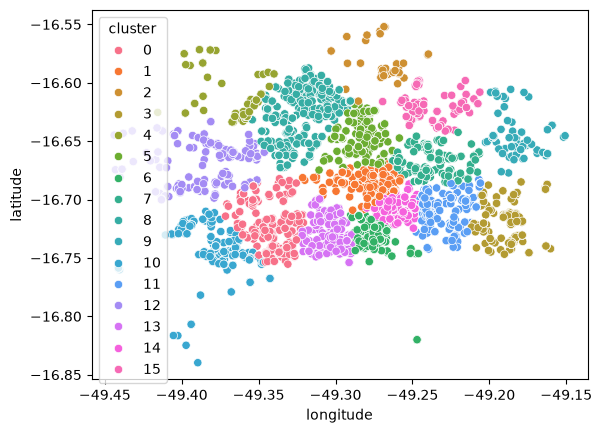

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=df, x="longitude", y="latitude", hue="cluster")
plt.show()

## Convertendo Dtypes

Antes de finalizar, vamos converter os dtypes.

In [24]:
df = df.convert_dtypes()

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 76 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   tipo_imovel                            7919 non-null   string  
 1   preco                                  7919 non-null   Int64   
 2   condominio                             4602 non-null   Int64   
 3   area_m2                                7919 non-null   Int64   
 4   quartos                                7918 non-null   Int64   
 5   banheiros                              7918 non-null   Int64   
 6   vagas                                  7286 non-null   Int64   
 7   piscina                                7919 non-null   boolean 
 8   espaco_gourmet                         7919 non-null   boolean 
 9   academia                               7919 non-null   boolean 
 10  spa_massagem                           7919 non-null   boolean 
 11  es

## Salvando o Dataset

Por fim, vamos salvar o dataset.

In [26]:
df.to_parquet("../data/processed/03_processed.parquet")